# Relatório de Análise e Métricas - Camada Gold
Este notebook responde às perguntas de negócio estipuladas utilizando dados limpos da Camada Silver e tabelas/views agregadas da Camada Gold.

In [1]:
#Importações e Configuração de Estilo#

import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from config import MYSQL_CONFIG

# Configurações globais de visualização
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

PARTE 1: Perguntas Diretas na Camada Silver (Consultas SQL + Gráficos)

Pergunta 1 — Os 5 órgãos com maior custo total?

--- Os 5 órgãos com maior custo total ---


,nome_orgao_superior,custo_total
0,Ministério da Justiça e Segurança Pública,4.869331e+08
1,Ministério da Defesa,1.560703e+08
2,Ministério da Educação,1.112913e+08
3,Ministério do Meio Ambiente e Mudança do Clima,4.969771e+07
4,Ministério da Previdência Social,4.041731e+07


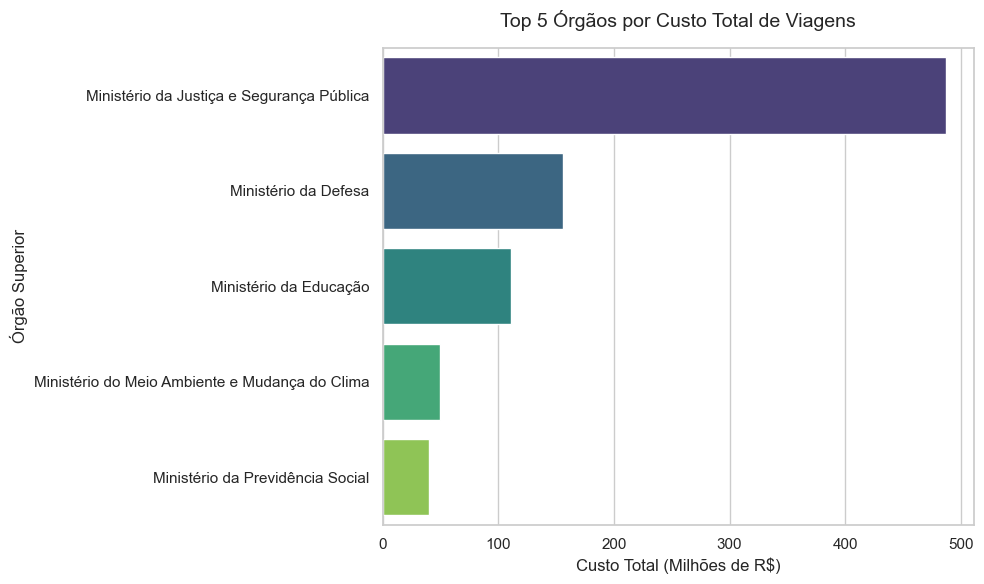

In [2]:
# Conexão
conn = mysql.connector.connect(**MYSQL_CONFIG)

query_1 = """
    SELECT nome_orgao_superior, SUM(valor_total) AS custo_total 
    FROM silver_viagem 
    GROUP BY nome_orgao_superior 
    ORDER BY custo_total DESC 
    LIMIT 5;
"""
df_1 = pd.read_sql(query_1, conn)

# Tabela
print("--- Os 5 órgãos com maior custo total ---")
display(df_1)


# Conexão e query
df_1 = pd.read_sql(query_1, conn)

# Cria uma coluna auxiliar com o valor em milhões
df_1["custo_total_mi"] = df_1["custo_total"] / 1_000_000

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=df_1, x="custo_total_mi", y="nome_orgao_superior", palette="viridis")

# Ajustes de títulos e eixos claros
plt.title("Top 5 Órgãos por Custo Total de Viagens", fontsize=14, pad=15)
plt.xlabel("Custo Total (Milhões de R$)", fontsize=12)
plt.ylabel("Órgão Superior", fontsize=12)
plt.tight_layout()
plt.show()

Pergunta 2 — Os 3 destinos com maior custo médio por viagem?

--- Top 3 Destinos com Maior Custo Médio por Viagem ---


,destino,custo_medio
0,Nossa Senhora Aparecida,125561.25
1,Tejupá,115175.00
2,Chavantes,114557.01


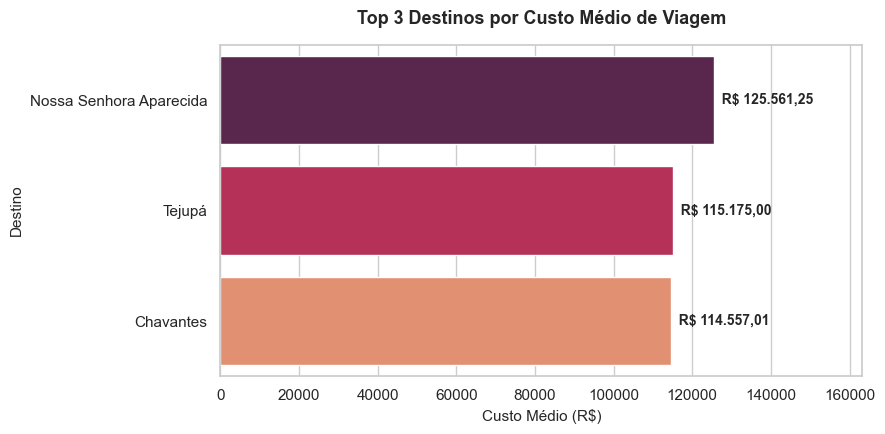

In [15]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Abre a conexão com o banco de dados
conn = mysql.connector.connect(**MYSQL_CONFIG)

try:
    # Query 2: Busca os 3 destinos (cidades) com maior custo médio por viagem
    query_2 = """
        SELECT 
            TRIM(t.destino_cidade) AS destino,
            AVG(v.valor_total) AS custo_medio
        FROM silver_viagem v
        INNER JOIN silver_trecho t ON v.id_viagem = t.id_viagem
        WHERE t.destino_cidade IS NOT NULL 
          AND TRIM(t.destino_cidade) != ''
          AND v.valor_total > 0
        GROUP BY TRIM(t.destino_cidade)
        ORDER BY custo_medio DESC
        LIMIT 3;
    """
    df_2 = pd.read_sql(query_2, conn)

    # 1. Exibição da Tabela de Resultados
    print("--- Top 3 Destinos com Maior Custo Médio por Viagem ---")
    display(df_2[['destino', 'custo_medio']])

    # 2. Construção da Visualização Gráfica
    fig, ax = plt.subplots(figsize=(9, 4.5))

    sns.barplot(
        data=df_2,
        x="custo_medio",
        y="destino",
        hue="destino",
        legend=False,
        palette="rocket",
        ax=ax
    )

    # Rótulos com os valores numéricos em R$ nas barras
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt=lambda x: f"  R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."),
            fontsize=10,
            fontweight='bold'
        )

    # Títulos e Eixos
    ax.set_title("Top 3 Destinos por Custo Médio de Viagem", fontsize=13, pad=15, fontweight="bold")
    ax.set_xlabel("Custo Médio (R$)", fontsize=11)
    ax.set_ylabel("Destino", fontsize=11)

    # Espaço extra no eixo X para evitar que o texto do valor R$ seja cortado
    ax.set_xlim(0, df_2['custo_medio'].max() * 1.30)

    plt.tight_layout()
    plt.show()

finally:
    conn.close()

Pergunta 3 — A viagem de maior duração e seu custo total?

--- Viagem de maior duração ---


,id_viagem,nome_viajante,destinos,duracao_dias,valor_total
0,0000000000020793594,Informações protegidas por sigilo,Informações protegidas por sigilo,378,120650.0


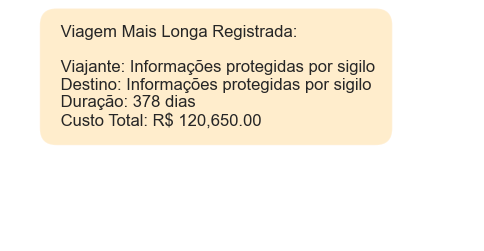

In [4]:
query_3 = """
    SELECT id_viagem, nome_viajante, destinos, duracao_dias, valor_total 
FROM silver_viagem 
WHERE duracao_dias > 0 
  AND valor_total > 0
  AND data_inicio IS NOT NULL 
  AND data_fim IS NOT NULL
ORDER BY duracao_dias DESC, valor_total DESC
LIMIT 1;
"""
df_3 = pd.read_sql(query_3, conn)

# Tabela
print("--- Viagem de maior duração ---")
display(df_3)

# Visualização de Destaque
fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('off')
texto = (
    f" Viagem Mais Longa Registrada:\n\n"
    f" Viajante: {df_3['nome_viajante'].iloc[0]}\n"
    f" Destino: {df_3['destinos'].iloc[0]}\n"
    f" Duração: {df_3['duracao_dias'].iloc[0]} dias\n"
    f" Custo Total: R$ {df_3['valor_total'].iloc[0]:,.2f}"
)
ax.text(0.1, 0.5, texto, fontsize=12, bbox=dict(facecolor='orange', alpha=0.2, boxstyle='round,pad=1'))
plt.show()

PARTE 2: Perguntas Utilizando a Camada Gold Agregada (View / Tabela)

Pergunta 4 — Qual o tipo de pagamento com maior valor médio?

--- Valor Médio por Tipo de Pagamento ---


,tipo_pagamento,valor_medio
0,DIÁRIAS,2078.280299
1,PASSAGEM,1878.344393
2,Serviço correlato: seguro,447.514653
3,RESTITUIÇÃO,245.702610


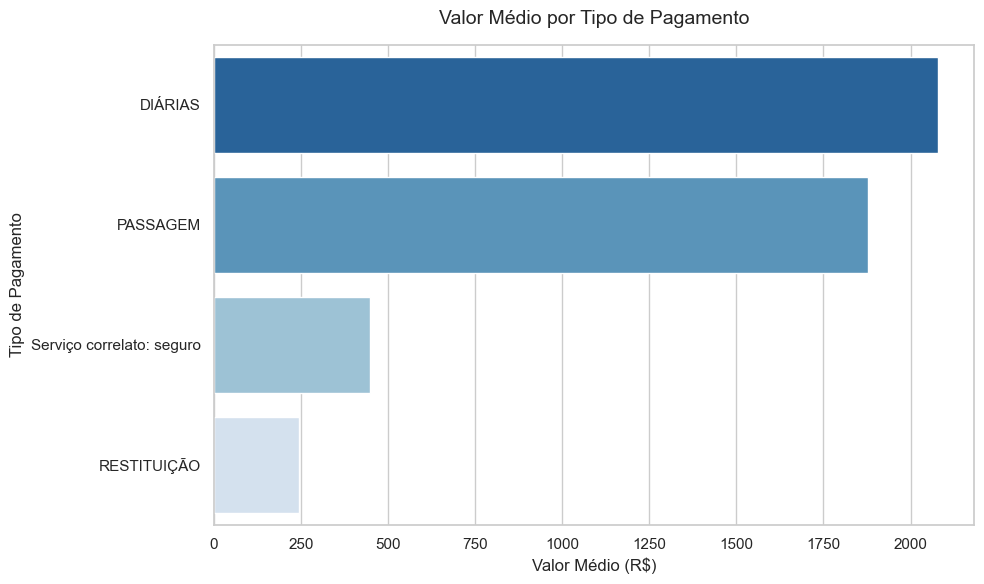

In [5]:
query_4 = """
    SELECT tipo_pagamento, AVG(valor) AS valor_medio 
    FROM silver_pagamento 
    GROUP BY tipo_pagamento 
    ORDER BY valor_medio DESC;
"""
df_4 = pd.read_sql(query_4, conn)

print("--- Valor Médio por Tipo de Pagamento ---")
display(df_4)

plt.figure()
sns.barplot(data=df_4, x="valor_medio", y="tipo_pagamento", palette="Blues_r")
plt.title("Valor Médio por Tipo de Pagamento", fontsize=14, pad=15)
plt.xlabel("Valor Médio (R$)", fontsize=12)
plt.ylabel("Tipo de Pagamento", fontsize=12)
plt.tight_layout()
plt.show()

Pergunta 5 — Qual o meio de transporte mais usado nos trechos e qual UF de destino aparece mais?

--- Meios de Transporte mais Utilizados ---


,meio_transporte,quantidade
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481



--- Top 5 UFs de Destino ---


,destino_uf,ocorrencias
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603


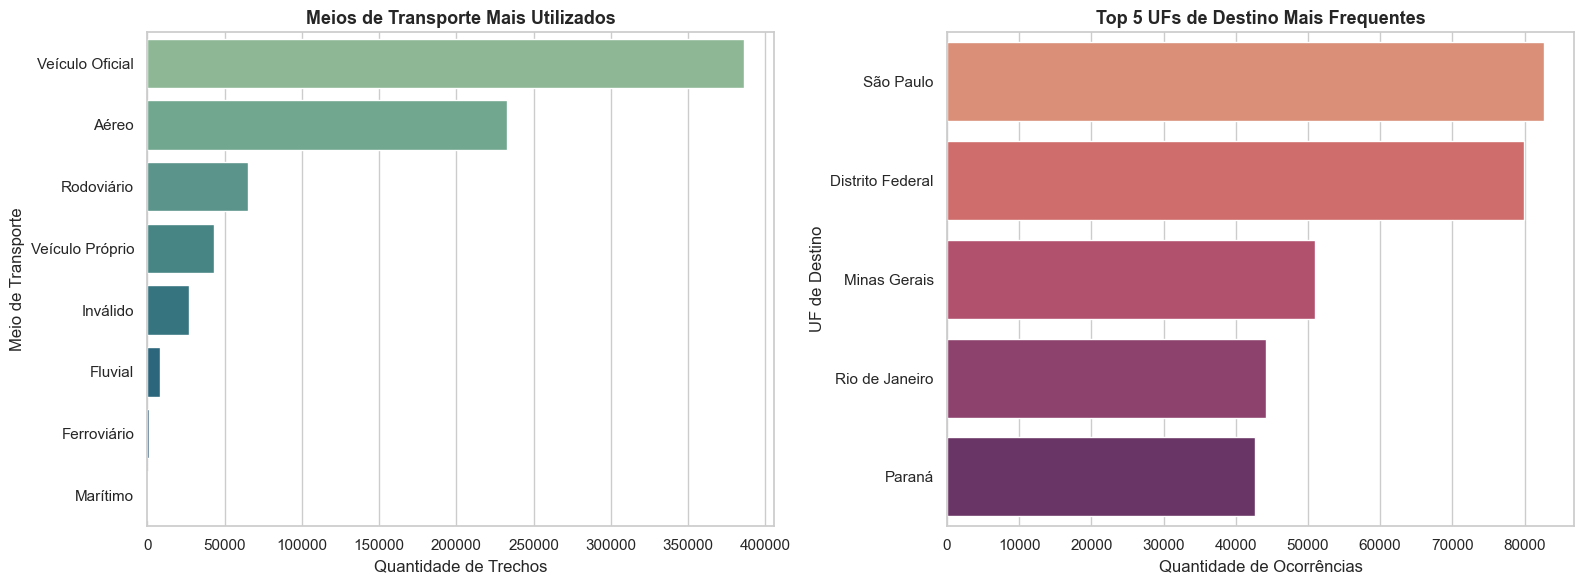

In [6]:
# Abre a conexão especificamente para esta célula
conn = mysql.connector.connect(**MYSQL_CONFIG)

try:
    # Consulta 5A: Meio de Transporte 
    query_5a = """
        SELECT meio_transporte, COUNT(*) AS quantidade 
        FROM silver_trecho 
        WHERE meio_transporte IS NOT NULL AND meio_transporte != ''
        GROUP BY meio_transporte 
        ORDER BY quantidade DESC;
    """
    df_5a = pd.read_sql(query_5a, conn)

    # Consulta 5B: UFs de Destino
    query_5b = """
        SELECT destino_uf, COUNT(*) AS ocorrencias 
        FROM silver_trecho 
        WHERE destino_uf IS NOT NULL AND destino_uf != ''
        GROUP BY destino_uf 
        ORDER BY ocorrencias DESC 
        LIMIT 5;
    """
    df_5b = pd.read_sql(query_5b, conn)

    # Exibe os DataFrames
    print("--- Meios de Transporte mais Utilizados ---")
    display(df_5a)
    print("\n--- Top 5 UFs de Destino ---")
    display(df_5b)

    # Gráfico Combinado (Subplots)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.barplot(ax=axes[0], data=df_5a, x="quantidade", y="meio_transporte", palette="crest")
    axes[0].set_title("Meios de Transporte Mais Utilizados", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Quantidade de Trechos")
    axes[0].set_ylabel("Meio de Transporte")

    sns.barplot(ax=axes[1], data=df_5b, x="ocorrencias", y="destino_uf", palette="flare")
    axes[1].set_title("Top 5 UFs de Destino Mais Frequentes", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Quantidade de Ocorrências")
    axes[1].set_ylabel("UF de Destino")

    plt.tight_layout()
    plt.show()

finally:
    # Garante o fechamento da conexão 
    conn.close()

#Pergunta 6 — Qual órgão pagou mais no total? (Consultando nossa View Gold)

In [7]:
# Abre uma conexão dedicada
conn = mysql.connector.connect(**MYSQL_CONFIG)

try:
    # Query que consulta a VIEW AGREGADA GOLD criada no banco
    query_6 = """
        SELECT nome_orgao_superior, custo_total_viagens 
        FROM gold_view_custo_orgao 
        ORDER BY custo_total_viagens DESC 
        LIMIT 1;
    """
    df_6 = pd.read_sql(query_6, conn)

    print("--- Órgão Líder em Custo de Viagens (Consulta via View Gold) ---")
    display(df_6)
    
    # Exibe um destaque visual simples do resultado
    orgao_nome = df_6['nome_orgao_superior'].iloc[0]
    custo_total = df_6['custo_total_viagens'].iloc[0]
    print(f"\n📊 O órgão que mais gastou foi o '{orgao_nome}' com o total acumulado de R$ {custo_total:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))

finally:
    # Garante o fechamento seguro da conexão
    conn.close()

--- Órgão Líder em Custo de Viagens (Consulta via View Gold) ---


,nome_orgao_superior,custo_total_viagens
0,Ministério da Justiça e Segurança Pública,4.869331e+08



📊 O órgão que mais gastou foi o 'Ministério da Justiça e Segurança Pública' com o total acumulado de R$ 486.933.121,65
